In [23]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


In [2]:
# ==========setup model ===========
llm=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.5,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [3]:
response=llm.invoke([HumanMessage(content="What is the capital of egypt?")]).content
print("Response from the model:")
response

Response from the model:


[{'type': 'text',
  'text': 'The capital of Egypt is **Cairo**.',
  'extras': {'signature': 'EjQKMgEMOdbH2QJlwq/90CTFSd9KIJufi3Tzp//pdt+X3z4CeVLWs4JlSMkM5DNdVhY1aIj+'}}]

In [5]:
response[0]['text']

'The capital of Egypt is **Cairo**.'

In [24]:
from pydantic import BaseModel, Field
from typing import List, Annotated
from operator import add

class GraphState(BaseModel):
    messages: Annotated[List[BaseMessage], add] = Field(
        default_factory=list,
        description="A list of messages in the graph state"
    )
    topic: str = Field(description="The topic for which social media content is being generated")

In [11]:
#==========setup prompt template ===========
# is designed specialy for linkedin content generation
def generate_linkedin_content(topic: str) -> str:
    " this function will use the agent to generate social media content and validate it using the pydantic model "

    prompt = f"""
    You are a social media content generator. Your task is to create engaging and informative content for LinkedIn based on the given topic. 
    Please provide the following:
    1. A brief post about the topic.
    2. use gen z style to curate the post for better engagement.
    3. Make sure the content is professional and suitable for LinkedIn.

    the user will provide you with a topic, and you will generate the content accordingly.
    User Topic: {topic}
    


    """
    return prompt


def curate_linkedin_prompt(post: str) -> str:
    " this function will use the agent to curate the generated social media content for better engagement "

    prompt = f"""
    You are a social media content curator. Your task is to take the generated post and curate it in a way that it becomes more engaging and suitable for LinkedIn. 
    Please use a style that resonates with Gen Z while maintaining professionalism.

    Here is the post that needs to be curated:
    {post}

    """
    return prompt

In [25]:
def create_linkedin_content(state: GraphState) -> GraphState:
    
    content_generation_prompt = HumanMessage(
        content=generate_linkedin_content(state.topic)
    )

    llm_response = llm.invoke([content_generation_prompt])
    generated_post = llm_response.content[0]["text"]

    # Keep existing messages and add new ones without manual append calls.
    return state.model_copy(
        update={
            "messages": state.messages + [
                content_generation_prompt,
                AIMessage(content=generated_post),
            ]
        }
    )

# test the function
state = GraphState(topic="write 3 tips for learning python in brief and engaging way")
output = create_linkedin_content(state)
print("Output state:")
print(output)

Output state:
messages=[HumanMessage(content='\n    You are a social media content generator. Your task is to create engaging and informative content for LinkedIn based on the given topic. \n    Please provide the following:\n    1. A brief post about the topic.\n    2. use gen z style to curate the post for better engagement.\n    3. Make sure the content is professional and suitable for LinkedIn.\n\n    the user will provide you with a topic, and you will generate the content accordingly.\n    User Topic: write 3 tips for learning python in brief and engaging way\n\n\n\n    ', additional_kwargs={}, response_metadata={}), AIMessage(content='Here is a LinkedIn post tailored with a professional yet Gen Z-friendly vibe:\n\n***\n\n**Headline: POV: You’re finally ready to learn Python. 🐍**\n\nLet’s be real—coding can feel like a fever dream at first, but Python is honestly the main character of programming languages for a reason. Whether you’re trying to automate your workflow or pivot int

In [26]:
output.messages

[HumanMessage(content='\n    You are a social media content generator. Your task is to create engaging and informative content for LinkedIn based on the given topic. \n    Please provide the following:\n    1. A brief post about the topic.\n    2. use gen z style to curate the post for better engagement.\n    3. Make sure the content is professional and suitable for LinkedIn.\n\n    the user will provide you with a topic, and you will generate the content accordingly.\n    User Topic: write 3 tips for learning python in brief and engaging way\n\n\n\n    ', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Here is a LinkedIn post tailored with a professional yet Gen Z-friendly vibe:\n\n***\n\n**Headline: POV: You’re finally ready to learn Python. 🐍**\n\nLet’s be real—coding can feel like a fever dream at first, but Python is honestly the main character of programming languages for a reason. Whether you’re trying to automate your workflow or pivot into data science, here’s

In [31]:
from langgraph.graph import StateGraph,START,END

#==========setup graph ===========
linkedin_graph = StateGraph(state_schema=GraphState)

linkedin_graph.add_node("create_linkedin_content", create_linkedin_content)

linkedin_graph.add_edge(START, "create_linkedin_content")
linkedin_graph.add_edge("create_linkedin_content", END)

# compile the graph
linkedin_graph=linkedin_graph.compile()

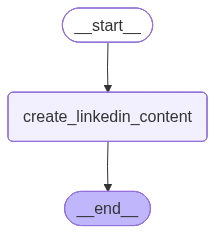

In [32]:
from IPython.display import Image,display
display(Image(linkedin_graph.get_graph().draw_mermaid_png()))

In [34]:
#==========setup intial state and run the graph ===========
output=linkedin_graph.invoke(state)

In [44]:
print(output["messages"][0].content)


    You are a social media content generator. Your task is to create engaging and informative content for LinkedIn based on the given topic. 
    Please provide the following:
    1. A brief post about the topic.
    2. use gen z style to curate the post for better engagement.
    3. Make sure the content is professional and suitable for LinkedIn.

    the user will provide you with a topic, and you will generate the content accordingly.
    User Topic: The impact of AI on the job market



    


In [45]:
print(output["topic"])

The impact of AI on the job market


In [42]:
print(output["messages"][1].content)

Here is a LinkedIn post crafted to be professional yet resonant with Gen Z’s perspective on the AI-driven job market.

***

**Headline: Is AI coming for our jobs, or just for our manual labor? 🤖✨**

Let’s be real: the "AI takeover" discourse is everywhere, and it’s giving major main character energy. 

I’ve been seeing a lot of panic about AI replacing roles, but I think we’re looking at it through the wrong lens. It’s not about AI replacing humans—it’s about humans who use AI replacing those who don’t. 

We’re moving into an era where "AI literacy" is the new soft skill. Whether it’s automating the repetitive tasks that drain our creative battery or using LLMs to brainstorm at 2x speed, the goal isn't to work *less*—it’s to work *smarter*. 

**Here’s the tea on how to stay ahead:**

✅ **Focus on the "Human" edge:** AI can generate the output, but it can’t replicate your unique lived experience, your intuition, or your ability to build genuine relationships. That’s your competitive adv